In [1]:
import numpy as np
import pandas as pd
import swc.aeon.io as io
import swc.aeon.io.reader as reader
from swc.aeon.schema.streams import Device
from swc.aeon.schema import core as stream
from swc.aeon.io.reader import Csv
import swc.aeon.io.video as video
import os
from dotmap import DotMap
import matplotlib.pyplot as plt
from pathlib import Path
from itertools import islice
import cv2
from scipy.signal import find_peaks

In [15]:
def normalise_series(series):
    return (series - series.min()) / (series.max() - series.min())

def get_camera_data(root: str, name: str):
    path = os.path.join(root, f"{name}/{name}.csv")
    data = pd.read_csv(path, header=0, names=["time"])
    data["_frame"] = data.index
    data["_path"] = os.path.splitext(path)[0] + ".avi"
    data.set_index("time", inplace=True)

    return data

def get_index_at_time(camera_data: pd.DataFrame, time: float):
    slice = camera_data.loc[camera_data.index <= time]
    return slice.iloc[[-1]]["_frame"].values[0]

def get_frame_at_index(camera_data: pd.DataFrame, index: int):
    return next(islice(camera_data, index, index+1))

def angle_cos(p0, p1, p2):
    d1, d2 = (p0-p1).astype('float'), (p2-p1).astype('float')
    return abs(np.dot(d1, d2) / np.sqrt(np.dot(d1, d1)*np.dot(d2, d2)))

## Landmark detection
def detect_landmarks(frame, blur: int, thresh1: int, thresh2: int):
    blurred = cv2.GaussianBlur(frame, (blur, blur), 0)
    edges = cv2.Canny(blurred, thresh1, thresh2)
    contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    squares = []
    for cnt in contours:
        cnt_len = cv2.arcLength(cnt, True)
        cnt = cv2.approxPolyDP(cnt, 0.02 * cnt_len, True)
        if len(cnt) == 4 and cv2.contourArea(cnt) > 2000 and cv2.isContourConvex(cnt):
            cnt = cnt.reshape(-1, 2)
            max_cos = np.max([angle_cos(cnt[i], cnt[(i+1) % 4], cnt[(i+2) % 4]) for i in range(4)])
            if max_cos < 0.3:
                M = cv2.moments(cnt)
                if M["m00"] != 0:
                    cx = int(M["m10"] / M["m00"])
                    cy = int(M["m01"] / M["m00"])
                squares.append((cnt, (cx, cy)))

    return squares

In [3]:
## Extract data from the subject camera
base_dir = "../../temp_data/sub-Tracking/ses-001_date-2026-07-23T14-51-35/"
# base_dir = "../../temp_data/sub-Tracking/ses-001_date-2026-07-24T09-35-26/"

subject_camera = get_camera_data(base_dir, "SubjectCamera")
subject_frames = video.frames(subject_camera)

vid_path = os.path.join(base_dir, "AnnotatedResult.mp4")
result = pd.DataFrame(columns=["frame_index", "frame_time", "detected_squares", "track_centroid_x", "track_centroid_y", "track_area", "aruco_centroid_x", "aruco_centroid_y", "aruco_area"])

annotated_frames = []
n_squares = []
for f, frame in enumerate(subject_frames):
    detected_squares = 0
    blur = -1
    while detected_squares < 2:
        blur += 2
        squares = detect_landmarks(frame, blur, 200, 100)
        detected_squares = len(squares)
        if blur > 40:
            squares = detect_landmarks(frame, 1, 200, 100)
            break

    n_squares.append(len(squares))
    track_centroid = (np.nan, np.nan)
    aruco_centroid = (np.nan, np.nan)
    track_area = np.nan
    aruco_area = np.nan
    if (len(squares) == 2):
        track_contour = squares[0] if (squares[0][1][0] < squares[1][1][0]) else squares[1]
        aruco_contour = squares[1] if (squares[0][1][0] < squares[1][1][0]) else squares[0]

        track_centroid = track_contour[1]
        aruco_centroid = aruco_contour[1]
        track_area = cv2.contourArea(track_contour[0])
        aruco_area = cv2.contourArea(aruco_contour[0])
        contours = cv2.drawContours(frame, [track_contour[0]], -1, (0, 255, 0), 1)
        contours = cv2.drawContours(contours, [aruco_contour[0]], -1, (255, 0, 0), 1)
        contours = cv2.circle(contours, track_centroid, 2, (0, 255, 0), -1)
        contours = cv2.circle(contours, aruco_centroid, 2, (255, 0, 0), -1)
    else:
        contours = frame

    annotated_frames.append(contours)
    result.loc[f] = [f, subject_camera.index[f], len(squares), track_centroid[0], track_centroid[1], track_area, aruco_centroid[0], aruco_centroid[1], aruco_area]

video.export(annotated_frames, vid_path, 60)

print(result)

      frame_index    frame_time  detected_squares  track_centroid_x  \
0             0.0  20769.393504               1.0               NaN   
1             1.0  20772.033600               1.0               NaN   
2             2.0  20772.040224               1.0               NaN   
3             3.0  20772.046912               1.0               NaN   
4             4.0  20772.053568               2.0             368.0   
...           ...           ...               ...               ...   
6804       6804.0  20817.386624               2.0             368.0   
6805       6805.0  20817.393280               2.0             368.0   
6806       6806.0  20817.399936               2.0             368.0   
6807       6807.0  20817.406624               2.0             368.0   
6808       6808.0  20817.413280               2.0             368.0   

      track_centroid_y  track_area  aruco_centroid_x  aruco_centroid_y  \
0                  NaN         NaN               NaN               NaN   

[(np.float64(0.013343999999051448), np.float64(11.5)), (np.float64(0.013343999999051448), np.float64(10.0)), (np.float64(0.020000000000436557), np.float64(11.25)), (np.float64(0.013343999999051448), np.float64(9.0)), (np.float64(-0.020000000000436557), np.float64(10.166666666666671)), (np.float64(0.006688000001304317), np.float64(11.0)), (np.float64(0.0), np.float64(12.0)), (np.float64(0.020000000000436557), np.float64(8.0)), (np.float64(0.026655999998183688), np.float64(11.200000000000003)), (np.float64(0.020000000000436557), np.float64(9.666666666666671)), (np.float64(0.013343999999051448), np.float64(10.800000000000004)), (np.float64(0.013344000002689427), np.float64(5.0)), (np.float64(0.013344000002689427), np.float64(5.0)), (np.float64(0.0066560000013851095), np.float64(11.142857142857153)), (np.float64(0.006688000001304317), np.float64(8.5)), (np.float64(0.04668800000217743), np.float64(16.5)), (np.float64(0.0066560000013851095), np.float64(9.0)), (np.float64(0.0), np.float64(8.0

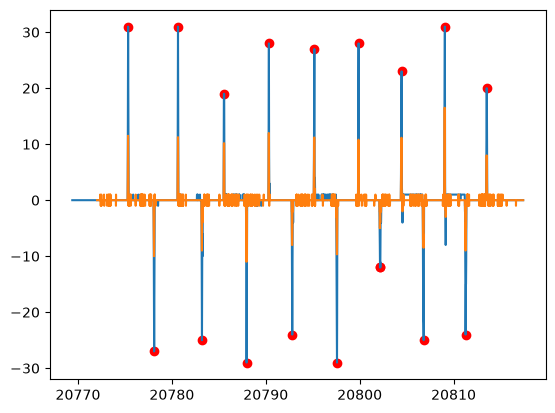

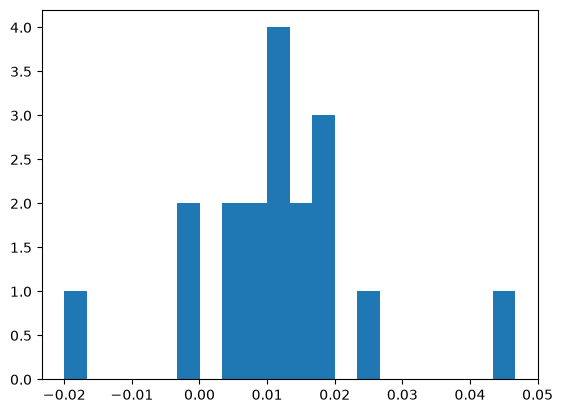

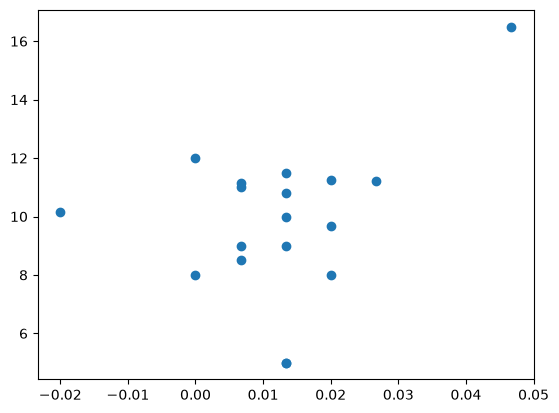

In [ ]:
start_track_index = result["track_centroid_x"].loc[result["track_centroid_x"].notnull()].index[0]

# find the peaks in the track centroid x data
track_x = (result["track_centroid_x"]-result["track_centroid_x"].iloc[start_track_index]).interpolate().fillna(0)
track_peaks, track_props = find_peaks(np.abs(track_x), prominence=10)

aruco_x = (result["aruco_centroid_x"]-result["aruco_centroid_x"].iloc[start_track_index]).interpolate().fillna(0).diff()

plt.figure()
plt.plot(result["frame_time"], track_x, label="Track Centroid X")
plt.plot(result["frame_time"], aruco_x, label="Aruco Centroid X")
plt.scatter(result["frame_time"].iloc[track_peaks], track_x.iloc[track_peaks], color='red', label='Peaks')

window = 0.1
diff_results = []
for pk in track_peaks:
    pk_time = result["frame_time"].iloc[pk]

    track_x_window = np.abs(track_x[(result["frame_time"] > pk_time-window) & (result["frame_time"] < pk_time+window)])
    aruco_x_window = np.abs(aruco_x[(result["frame_time"] > pk_time-window) & (result["frame_time"] < pk_time+window)])
    max_aruco_vel = np.max(aruco_x_window)

    norm_track_x = normalise_series(track_x_window)
    norm_aruco_x = normalise_series(aruco_x_window)
    track_x_peak_time = result["frame_time"].iloc[norm_track_x.index].iloc[np.argmax(norm_track_x)]
    aruco_x_peak_time = result["frame_time"].iloc[norm_aruco_x.index].iloc[np.argmax(norm_aruco_x)]
    diff_results.append((track_x_peak_time - aruco_x_peak_time, max_aruco_vel))

print(diff_results)

plt.figure()
plt.hist([d[0] for d in diff_results], bins=20)

plt.figure()
plt.scatter([d[1] for d in diff_results], [d[0] for d in diff_results])

# ## Example peak plot
# pk = track_peaks[8]
# pk_time = result["frame_time"].iloc[pk]
# window = 0.1

# track_x_window = normalise_series(np.abs(track_x[(result["frame_time"] > pk_time-window) & (result["frame_time"] < pk_time+window)]))
# aruco_x_window = normalise_series(np.abs(aruco_x[(result["frame_time"] > pk_time-window) & (result["frame_time"] < pk_time+window)]))
# diff_peaks = np.argmax(track_x_window) - np.argmax(aruco_x_window)
# print(result["frame_time"].iloc[track_x_window.index].iloc[np.argmax(track_x_window)])

# track_x_peak_time = result["frame_time"].iloc[track_x_window.index].iloc[np.argmax(track_x_window)]
# aruco_x_peak_time = result["frame_time"].iloc[aruco_x_window.index].iloc[np.argmax(aruco_x_window)]
# print(track_x_peak_time -aruco_x_peak_time)

# plt.figure()
# plt.plot(result["frame_time"].iloc[track_x_window.index], track_x_window, label="Track Centroid X")
# plt.scatter(track_x_peak_time, track_x_window.iloc[np.argmax(track_x_window)], color='red', label='Track Peak')
# plt.plot(result["frame_time"].iloc[aruco_x_window.index], aruco_x_window, label="Aruco Centroid X")
# plt.scatter(aruco_x_peak_time, aruco_x_window.iloc[np.argmax(aruco_x_window)], color='blue', label='Aruco Peak')
# plt.xlabel("Frame Time")
# plt.ylabel("Normalized Position")
# plt.title("Windowed Data")
# plt.legend()
# plt.show()